In [1]:
import torch
if torch.cuda.is_available():
    print(f"Super! Koristiš GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU nije pronađen. Provjeri postavke u Runtime izborniku.")

Super! Koristiš GPU: Tesla T4


In [2]:
import os


os.environ['KAGGLE_USERNAME'] = "ivonapranjic"
os.environ['KAGGLE_KEY'] = "KGAT_f7d98dab9d6df3a828a8330f9b0273f9"


!mkdir -p ~/.kaggle
!echo '{"username":"'$KAGGLE_USERNAME'","key":"'$KAGGLE_KEY'"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json


print("Skidanje podataka započeto...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip
print("Gotovo! Podaci su spremni.")

Skidanje podataka započeto...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.28G/2.29G [00:18<00:00, 88.8MB/s]
100% 2.29G/2.29G [00:18<00:00, 132MB/s] 
Gotovo! Podaci su spremni.


Provjera balansa skupova(klasa):

In [3]:
def count_files(directory):
  for root, dirs, files in os.walk(directory):
    if not dirs:
      print(f"Folder: {os.path.basename(root)} | Broj slika: {len(files)}")

print("Trening skup")
count_files('chest_xray/train')
print("Test skup")
count_files('chest_xray/test')

Trening skup
Folder: PNEUMONIA | Broj slika: 3875
Folder: NORMAL | Broj slika: 1341
Test skup
Folder: PNEUMONIA | Broj slika: 390
Folder: NORMAL | Broj slika: 234


Vizualna usporedba, inicijalna vizualizacija podataka s kojima radimo:

Nasumični uzorci slika zdravih pluća (normal):


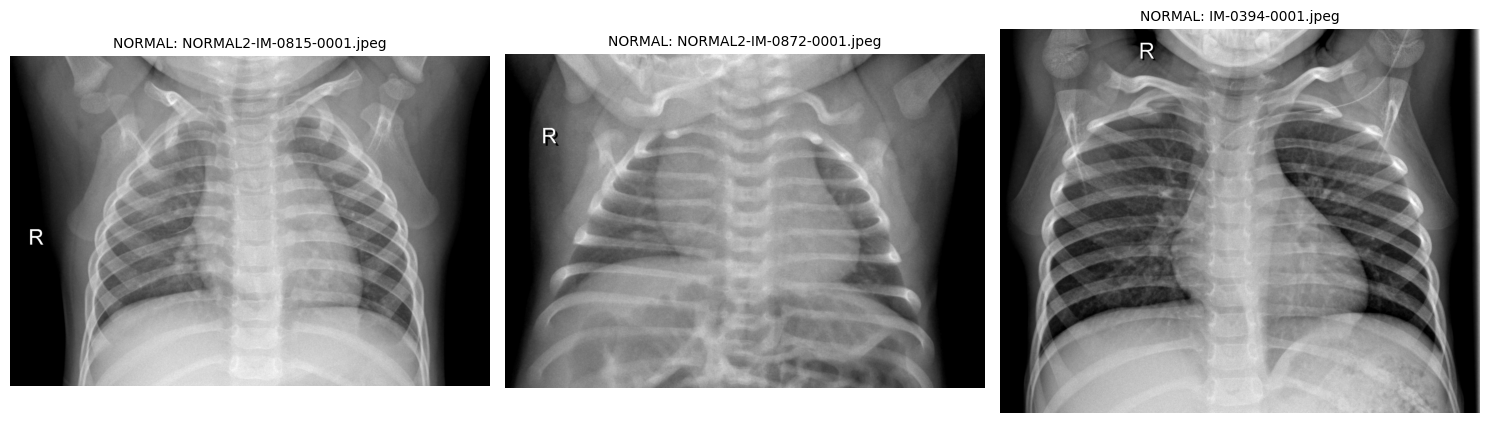


 Nasumični uzorci slika pluća (pneumonia):


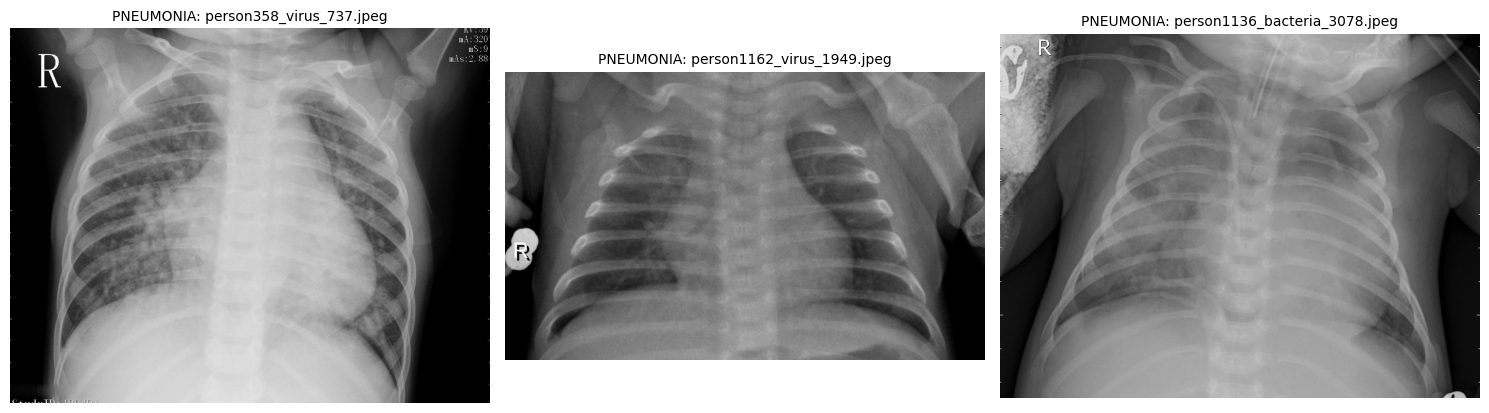

In [4]:
import matplotlib.pyplot as plt
import cv2
import os
import random

def plot_random_samples(condition):
  path=f'chest_xray/train/{condition}'
  all_images=os.listdir(path)
  random_images=random.sample(all_images, 3)

  plt.figure(figsize=(15,10))
  for i, img_name in enumerate(random_images):
    img_path=os.path.join(path, img_name)
    img=cv2.imread(img_path)
    img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"{condition}: {img_name}", fontsize=10)
    plt.axis('off')

  plt.tight_layout()
  plt.show()

print("Nasumični uzorci slika zdravih pluća (normal):")
plot_random_samples('NORMAL')

print("\n Nasumični uzorci slika pluća (pneumonia):")
plot_random_samples('PNEUMONIA')

Izrada baseline modela korištenjem transfer learninga (VGG16):

In [5]:
import torch
import torch.nn as nn
from torchvision import models

model=models.vgg16(pretrained=True)

for param in model.features.parameters():
  param.requires_grad=False

num_features=model.classifier[6].in_features
model.classifier[6]=nn.Linear(num_features, 2)

#prebacivanje na gpu
device=torch.device("cuda"if torch.cuda.is_available() else "cpu")
model=model.to(device)

print(model.classifier)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 69.2MB/s]


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)


Definiranje loss funkcije i optimizatora (Adam):

In [6]:
import torch.optim as optim

criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
print("Loss i optimizator uspješno definirani")

Loss i optimizator uspješno definirani


Normalizacija i priprema podataka

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#VGG16 zahtijeva 224x224 i normalizaciju specifičnu za ImageNet
data_transforms=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

])

train_dataset=datasets.ImageFolder('chest_xray/train', transform=data_transforms)
test_dataset=datasets.ImageFolder('chest_xray/test', transform=data_transforms)

train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Uspješno učitano {len(train_dataset)} slika za trening")
print(f"Uspješno učitano {len(test_dataset)} slika za test")
print(f"Mapiranje klasa: {train_dataset.class_to_idx}")

Uspješno učitano 5216 slika za trening
Uspješno učitano 624 slika za test
Mapiranje klasa: {'NORMAL': 0, 'PNEUMONIA': 1}


Pomoćna fja za izračun metrika:

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def calculate_metrics(y_true, y_pred):
  acc=accuracy_score(y_true, y_pred)
  prec=precision_score(y_true, y_pred, zero_division=0)
  rec=recall_score(y_true, y_pred, zero_division=0)
  f1=f1_score(y_true, y_pred, zero_division=0)

  return acc, prec, rec, f1

Inicijalizacija rječnika za praćenje napretka:

In [9]:
history={
    'train_loss': [], 'train_acc': [], 'train_prec': [], 'train_rec': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_prec': [], 'val_rec': [], 'val_f1': []
}

print("Rječnik za praćenje napretka uspješno inicijaliziran")

Rječnik za praćenje napretka uspješno inicijaliziran


Training Loop:

In [10]:
import numpy as np
from tqdm import tqdm

def train_baseline_model(model, train_loader, test_loader, criterion, optimizer, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    for epoch in range(epochs):
        print(f"\nEpoha {epoch+1}/{epochs}")

        # TRENING
        model.train()
        train_loss, train_preds, train_targets = 0.0, [], []

        for inputs, labels in tqdm(train_loader, desc="Treniranje"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad() # resetiranje gradijenata
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward() # backpropagation
            optimizer.step() # azuriranje tezina

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(labels.cpu().numpy())



        # računanje metrika za trening
        t_loss = train_loss / len(train_loader.dataset)
        t_acc, t_prec, t_rec, t_f1 = calculate_metrics(train_targets, train_preds)

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['train_prec'].append(t_prec)
        history['train_rec'].append(t_rec)
        history['train_f1'].append(t_f1)

        # VALIDACIJA
        model.eval()
        val_loss, val_preds, val_targets = 0.0, [], []

        with torch.no_grad():
            for inputs, labels in tqdm(test_loader, desc="Validacija"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

        v_loss = val_loss / len(test_loader.dataset)
        v_acc, v_prec, v_rec, v_f1 = calculate_metrics(val_targets, val_preds)

        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['val_prec'].append(v_prec)
        history['val_rec'].append(v_rec)
        history['val_f1'].append(v_f1)

        print(f"KRAJ EPOHE {epoch+1}")
        print(f"Trening - Loss: {t_loss:.4f}, Acc: {t_acc:.4f}, F1: {t_f1:.4f}")
        print(f"Validacija - Loss: {v_loss:.4f}, Acc: {v_acc:.4f}, F1: {v_f1:.4f}")

# pokretanje:
train_baseline_model(model, train_loader, test_loader, criterion, optimizer, epochs=5)


Epoha 1/5


Validacija: 100%|██████████| 20/20 [00:15<00:00,  1.27it/s]


KRAJ EPOHE 1
Trening - Loss: 0.4191, Acc: 0.9356, F1: 0.9566
Validacija - Loss: 7.6102, Acc: 0.6442, F1: 0.7784

Epoha 2/5


Validacija: 100%|██████████| 20/20 [00:19<00:00,  1.05it/s]


KRAJ EPOHE 2
Trening - Loss: 0.3151, Acc: 0.9601, F1: 0.9732
Validacija - Loss: 1.5717, Acc: 0.8638, F1: 0.8984

Epoha 3/5


...

KRAJ EPOHE 3
Trening - Loss: 0.1351, Acc: 0.9774, F1: 0.9848
Validacija - Loss: 2.3563, Acc: 0.8173, F1: 0.8716

Epoha 4/5


Validacija: 100%|██████████| 20/20 [00:19<00:00,  1.05it/s]


KRAJ EPOHE 4
Trening - Loss: 0.1057, Acc: 0.9803, F1: 0.9867
Validacija - Loss: 4.9559, Acc: 0.7821, F1: 0.8512

Epoha 5/5


Validacija: 100%|██████████| 20/20 [00:19<00:00,  1.01it/s]

KRAJ EPOHE 5
Trening - Loss: 0.1698, Acc: 0.9774, F1: 0.9848
Validacija - Loss: 3.1280, Acc: 0.8173, F1: 0.8719


Spremanje baseline modela

In [11]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(model.state_dict(), '/content/drive/MyDrive/vgg16_baseline_pneumonia.pth')
print("Spremljeno na drive")

Mounted at /content/drive
Spremljeno na drive


Vizualizacija rezultata baseline modela.

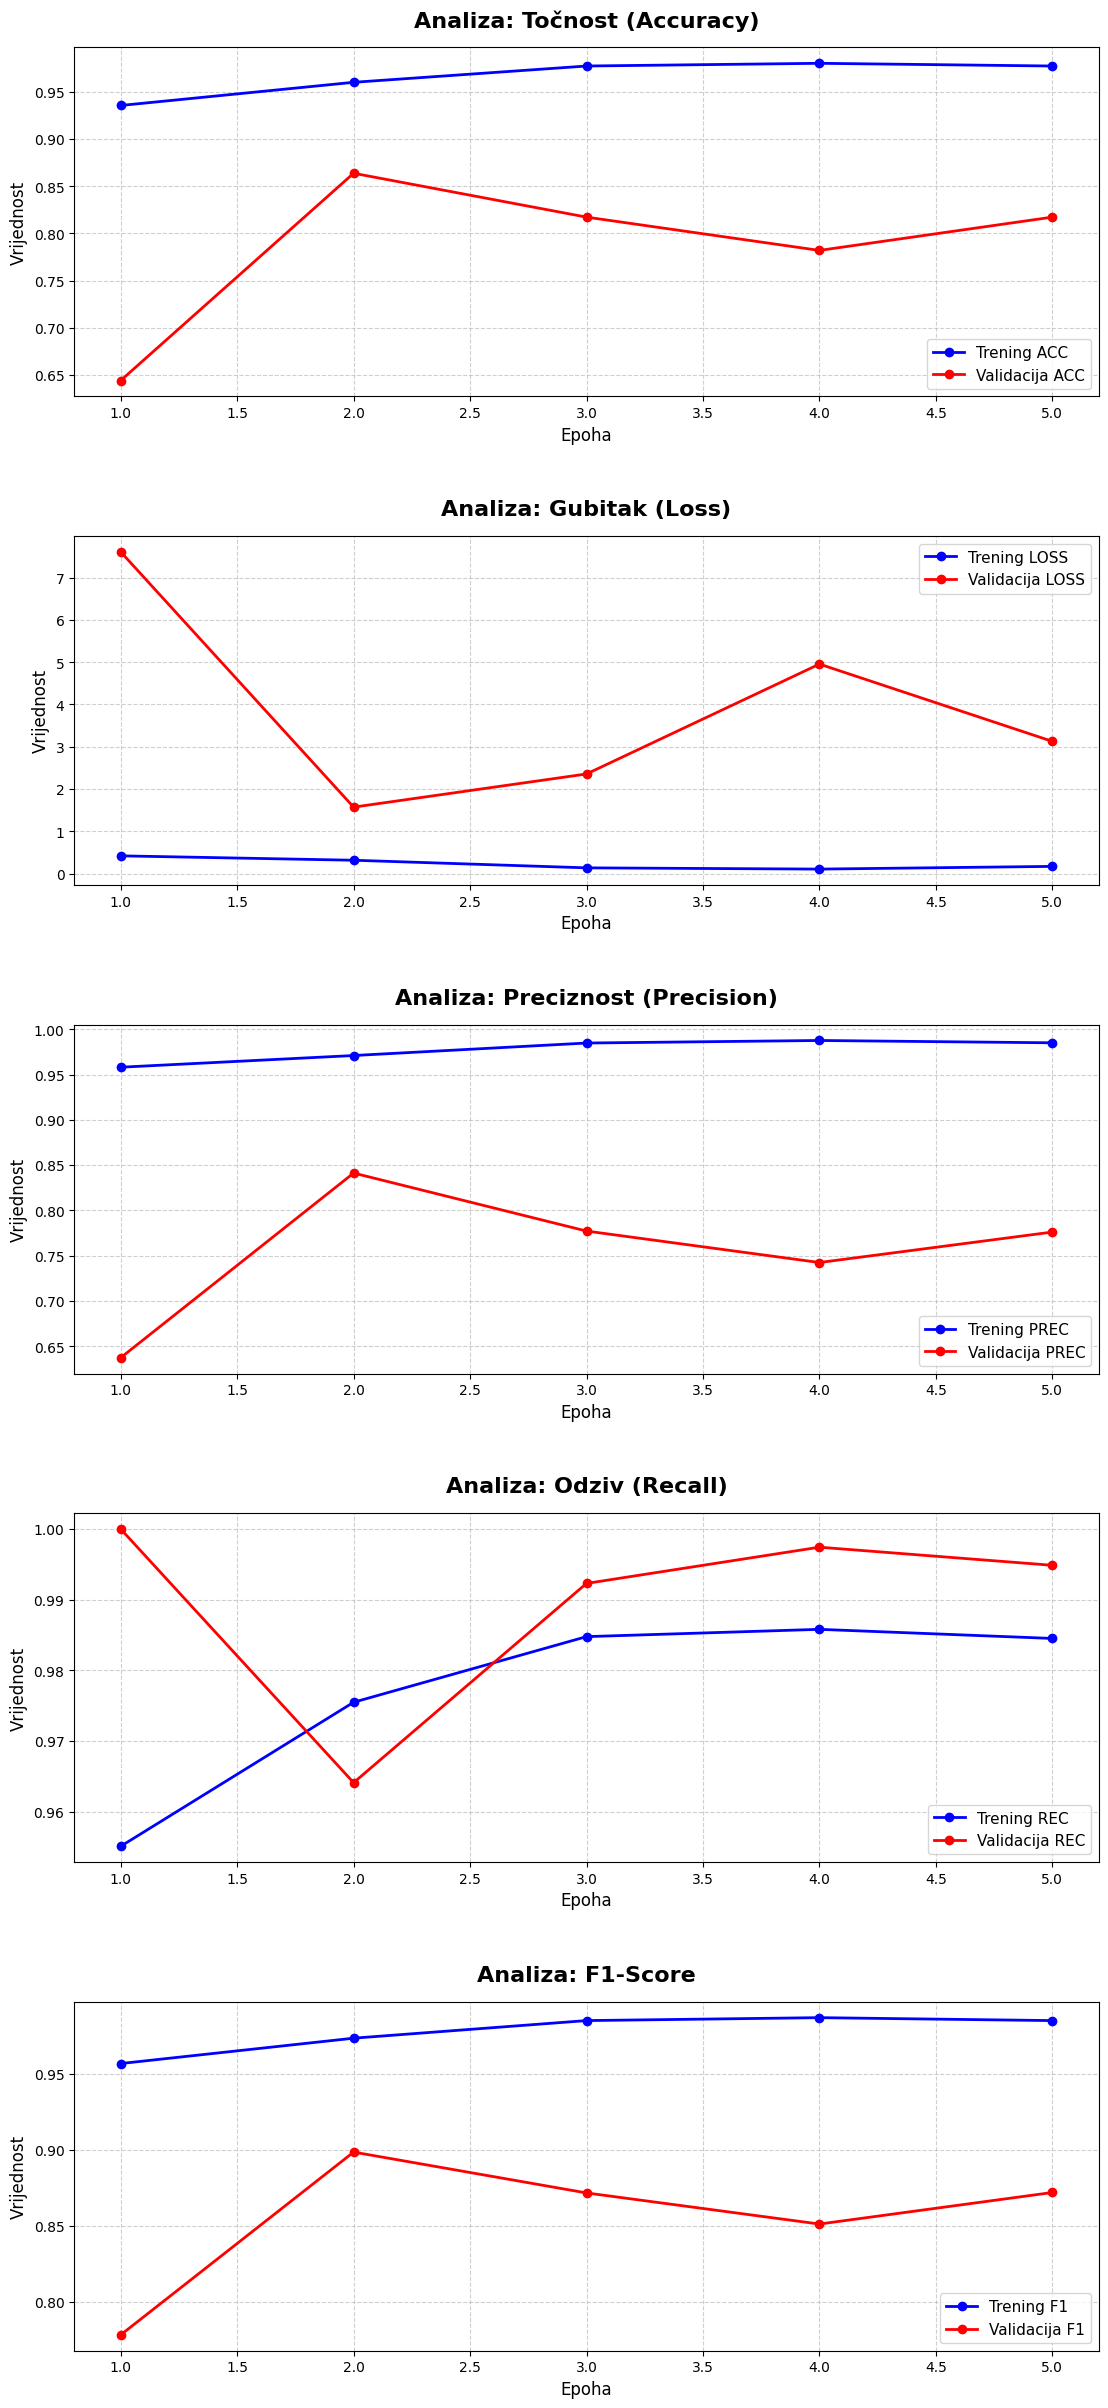

In [12]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    epochs = range(1, len(history['train_acc']) + 1)


    metrics = [
        ('acc', 'Točnost (Accuracy)'),
        ('loss', 'Gubitak (Loss)'),
        ('prec', 'Preciznost (Precision)'),
        ('rec', 'Odziv (Recall)'),
        ('f1', 'F1-Score')
    ]


    plt.figure(figsize=(12, 25))

    for i, (m_key, m_name) in enumerate(metrics, 1):
        plt.subplot(5, 1, i)

        train_values = history[f'train_{m_key}']
        val_values = history[f'val_{m_key}']

        plt.plot(epochs, train_values, 'b-o', linewidth=2, label=f'Trening {m_key.upper()}')
        plt.plot(epochs, val_values, 'r-o', linewidth=2, label=f'Validacija {m_key.upper()}')

        plt.title(f'Analiza: {m_name}', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Epoha', fontsize=12)
        plt.ylabel('Vrijednost', fontsize=12)
        plt.legend(loc='best', fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.6)


        plt.tight_layout(pad=4.0)

    plt.show()


plot_metrics(history)

Priprema AL initial poola:

In [13]:
from threading import active_count
import numpy as np
from torch.utils.data import Subset, DataLoader
#definirati početni broj slika:
INITIAL_SAMPLES=100

#uzimamo indekse svih slika iz trening skupa
all_indices=np.arange(len(train_dataset))
np.random.shuffle(all_indices)

#dijelimo na labeled i unlabeled(initial pool)
labeled_indices=all_indices[:INITIAL_SAMPLES].tolist()
unlabeled_indices=all_indices[INITIAL_SAMPLES:].tolist()

print(f"Početni set labeled: {len(labeled_indices)}")
print(f"Početni set unlabeled - initial pool: {len(unlabeled_indices)}")

#fja za kreiranje loadera od trenutno označenih slika
def get_active_loaders(labeled_indices):
  active_subset=Subset(train_dataset, labeled_indices)
  return DataLoader(active_subset, batch_size=32, shuffle=True)

active_loader=get_active_loaders(labeled_indices)



Početni set labeled: 100
Početni set unlabeled - initial pool: 5116


Sada model "vidi" samo 100 označenih slika, a preostale su u initial poolu - pravimo se da ne znamo njihovu labelu.

Fja za izbor slika s najvećom nesigurnošću modela:

In [24]:
import torch.nn.functional as F

def get_uncertain_samples(model, unlabeled_indices, train_dataset, n_samples=100):
  model.eval()
  device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

  #loader neoznačenih slika:
  unlabeled_loader=DataLoader(Subset(train_dataset, unlabeled_indices), batch_size=64, shuffle=False)

  all_probs=[]
  with torch.no_grad():
    for inputs, _ in unlabeled_loader:
      inputs=inputs.to(device)
      outputs=model(inputs)
      probs=F.softmax(outputs, dim=1)
      all_probs.append(probs.cpu())

  all_probs=torch.cat(all_probs)

  #gledamo razliku između vjerojatnosti za klasu 1 i klasu 0
  diff=torch.abs(all_probs[:,0] - all_probs[:,1])

  #sortiramo po nesigurnosti
  _, sorted_idx=torch.sort(diff)

  #uzmemo prvih n_samples indexa
  new_indices=[unlabeled_indices[i] for i in sorted_idx[:n_samples]]

  return new_indices

AL petlja +  metrike:

In [25]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

#Rječnik za spremanje AL povijesti:
al_history={
    'samples_count':[],
    'test_acc':[], 'test_prec':[], 'test_rec':[], 'test_f1':[], 'test_loss':[]
}

def evaluate_model_full(model, test_loader, criterion):
  model.eval()
  device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
  running_loss=0
  total=0
  correct=0
  all_labels=[]
  all_preds=[]

  with torch.no_grad():
    for inputs, labels in test_loader:
      inputs, labels=inputs.to(device), labels.to(device)
      outputs=model(inputs)
      loss=criterion(outputs, labels)

      _, preds=torch.max(outputs, 1)
      running_loss+=loss.item()*inputs.size(0)

      total+=labels.size(0)
      correct+=(preds==labels).sum().item()

      all_labels.extend(labels.cpu().numpy())
      all_preds.extend(preds.cpu().numpy())

  test_loss=running_loss/len(test_loader.dataset)
  test_acc=correct/total
  prec=precision_score(all_labels, all_preds)
  rec=recall_score(all_labels, all_preds)
  f1=f1_score(all_labels, all_preds)

  return test_loss, test_acc, prec, rec, f1

In [26]:
N_ITERATIONS=5 #Koliko puta cemo traziti nove slike
SAMPLES_PER_ITER=100 #Koliko slika dodajemo u svakoj rundi
EPOCHS_PER_ITER=3 #Broj epoha treniranja u svakoj rundi

criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(), lr=0.00001)

print("Pocetak AL ciklusa\n")

for i in range(N_ITERATIONS):
  print(f"Runda:{i+1} (Broj slika: {len(labeled_indices)})")

  model.train()
  active_loader=get_active_loaders(labeled_indices)
  for epoch in range(EPOCHS_PER_ITER):
    for inputs, labels in active_loader:
      inputs, labels=inputs.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs=model(inputs)
      loss=criterion(outputs, labels)
      loss.backward()
      optimizer.step()

  #evaluacija na testnom skupu:
  t_loss, t_acc, t_prec, t_rec, t_f1=evaluate_model_full(model, test_loader, criterion)

  #spremi rezultate:
  al_history['samples_count'].append(len(labeled_indices))
  al_history['test_acc'].append(t_acc)
  al_history['test_prec'].append(t_prec)
  al_history['test_rec'].append(t_rec)
  al_history['test_f1'].append(t_f1)
  al_history['test_loss'].append(t_loss)

  print(f"Test acc: {t_acc:.4f} | f1: {t_f1:.4f} | recc: {t_rec:.4f} | prec: {t_prec:.4f} | loss: {t_loss:.4f}")

  #odaberi nove teške slike za sljedeću rundu:
  if i< N_ITERATIONS - 1:
    new_samples=get_uncertain_samples(model, unlabeled_indices, train_dataset, n_samples=SAMPLES_PER_ITER)
    #prebaci ih iz neoznacenih u oznacene
    labeled_indices.extend(new_samples)
    for idx in new_samples:
      unlabeled_indices.remove(idx)


Pocetak AL ciklusa

Runda:1 (Broj slika: 100)
Test acc: 0.8237 | f1: 0.8758 | recc: 0.9949 | prec: 0.7823 | loss: 3.2689
Runda:2 (Broj slika: 200)
Test acc: 0.8125 | f1: 0.8690 | recc: 0.9949 | prec: 0.7714 | loss: 3.4659
Runda:3 (Broj slika: 300)
Test acc: 0.8141 | f1: 0.8700 | recc: 0.9949 | prec: 0.7729 | loss: 3.5452
Runda:4 (Broj slika: 400)
Test acc: 0.8141 | f1: 0.8700 | recc: 0.9949 | prec: 0.7729 | loss: 3.5770
Runda:5 (Broj slika: 500)
Test acc: 0.8141 | f1: 0.8700 | recc: 0.9949 | prec: 0.7729 | loss: 3.6108


Vizualizacija AL:

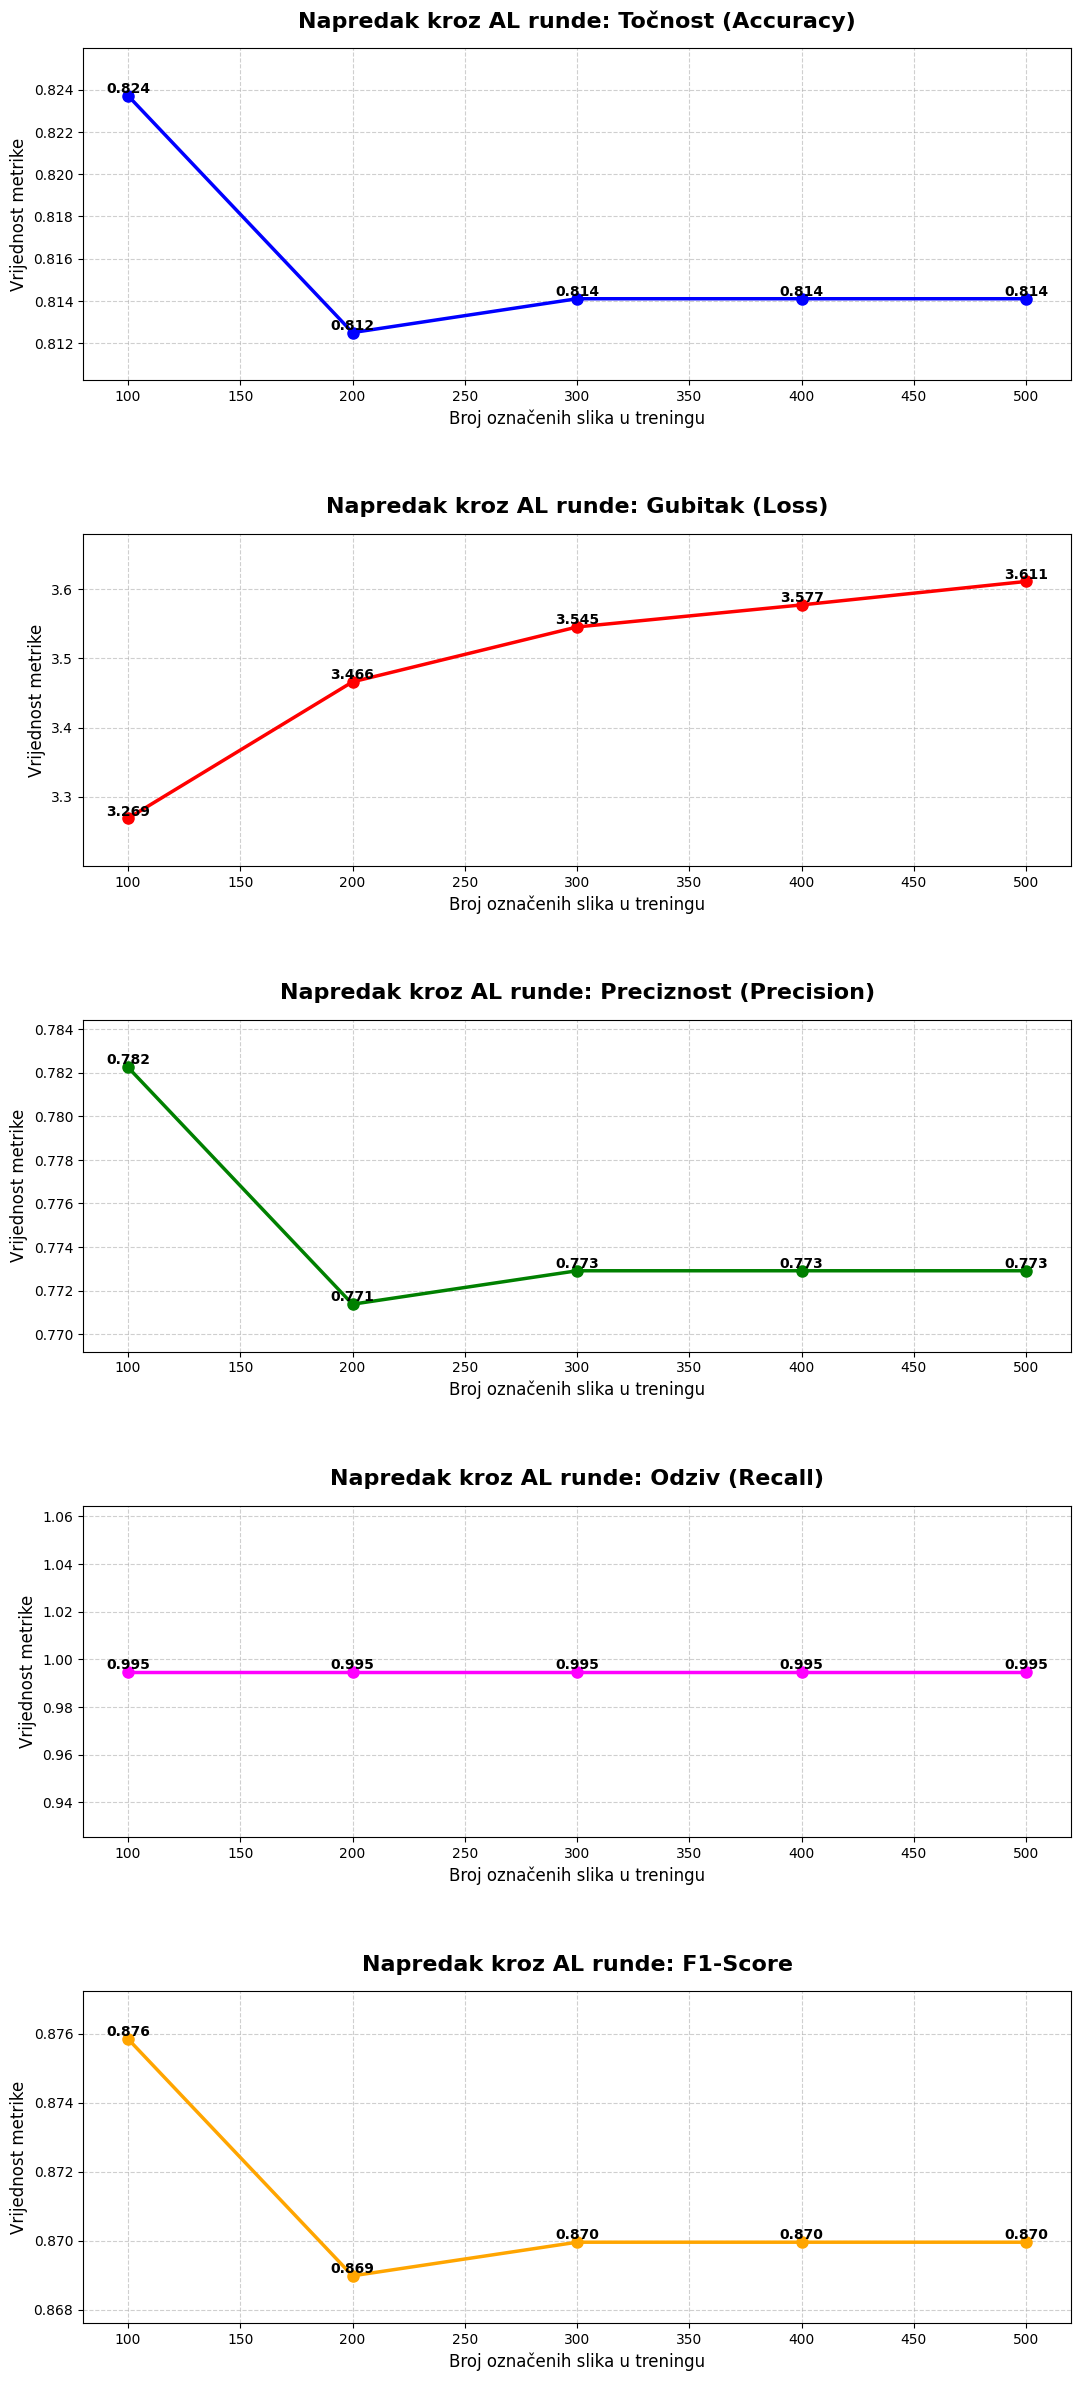

In [27]:
import matplotlib.pyplot as plt

def plot_al_progress(history):
    x = history['samples_count']


    metrics = [
        ('test_acc', 'Točnost (Accuracy)', 'blue'),
        ('test_loss', 'Gubitak (Loss)', 'red'),
        ('test_prec', 'Preciznost (Precision)', 'green'),
        ('test_rec', 'Odziv (Recall)', 'magenta'),
        ('test_f1', 'F1-Score', 'orange')
    ]


    plt.figure(figsize=(12, 25))

    for i, (key, name, color) in enumerate(metrics, 1):

        plt.subplot(5, 1, i)


        plt.plot(x, history[key], marker='o', linestyle='-', color=color, linewidth=2.5, markersize=8)


        for val_x, val_y in zip(x, history[key]):
            plt.text(val_x, val_y, f'{val_y:.3f}', va='bottom', ha='center', fontsize=10, fontweight='bold')


        plt.title(f'Napredak kroz AL runde: {name}', fontsize=16, fontweight='bold', pad=15)
        plt.xlabel('Broj označenih slika u treningu', fontsize=12)
        plt.ylabel('Vrijednost metrike', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)


        plt.margins(y=0.2)


    plt.tight_layout(pad=5.0)
    plt.show()


plot_al_progress(al_history)

Confusion matrix za finalni rezultat:

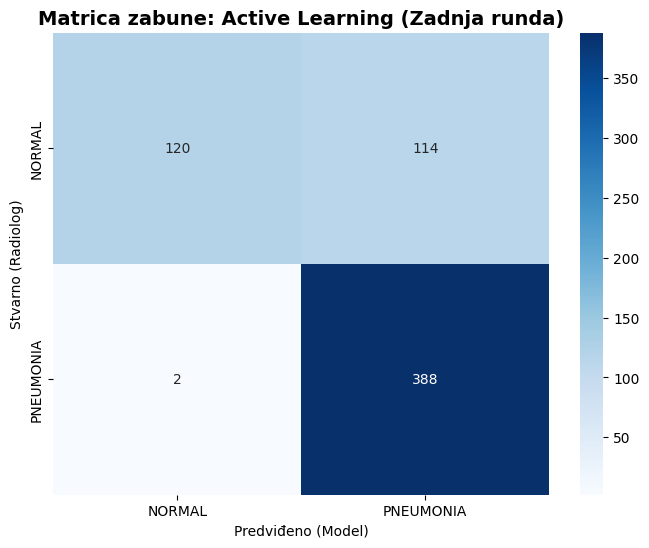

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_final_confusion_matrix(model, test_loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())


    cm = confusion_matrix(all_labels, all_preds)


    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.xlabel('Predviđeno (Model)')
    plt.ylabel('Stvarno (Radiolog)')
    plt.title('Matrica zabune: Active Learning (Zadnja runda)', fontsize=14, fontweight='bold')
    plt.show()


plot_final_confusion_matrix(model, test_loader)